# Plant Disease Classification using Google ViT-Base-Patch16-224

This notebook trains a Vision Transformer model using the pretrained `google/vit-base-patch16-224` from Hugging Face.

**Model**: Google ViT-Base (86M parameters)  
**Input**: 224x224 images with 16x16 patches  
**Dataset**: Multi-crop plant disease classification

## 1. Install Required Packages

In [ ]:
# Install transformers and other required packages for MacBook
!pip install -q transformers datasets pillow torch torchvision scikit-learn accelerate

## 2. Import Dependencies

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import json
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from transformers import ViTForImageClassification, ViTImageProcessor
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

# MacBook-specific device setup
print("=" * 60)
print("SYSTEM CONFIGURATION")
print("=" * 60)
print(f"PyTorch version: {torch.__version__}")

# Check for Apple Silicon MPS (Metal Performance Shaders)
try:
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        device = torch.device("mps")
        print("✓ Using Apple Silicon GPU (MPS)")
        
        # Quick test to ensure MPS is working
        try:
            test_tensor = torch.ones(1, device=device)
            print("✓ MPS device test successful")
        

print(f"Active device: {device}")
print("=" * 60)

SYSTEM CONFIGURATION
PyTorch version: 2.9.1
✓ Using Apple Silicon GPU (MPS)
✓ MPS device test successful
Active device: mps


## 3. Setup Paths and Configuration

In [8]:
# Set paths
base_path = os.getcwd()
train_dir = os.path.join(base_path, 'train')
valid_dir = os.path.join(base_path, 'valid')
test_dir = os.path.join(base_path, 'test')

print(f"Base path: {base_path}")
print(f"Train directory: {train_dir}")
print(f"Valid directory: {valid_dir}")
print(f"Test directory: {test_dir}")

# Configuration optimized for MacBook
MODEL_NAME = "google/vit-base-patch16-224"
IMG_SIZE = 224

# Adjust batch size based on available memory
# For Apple Silicon: 16-32 works well
# For Intel Mac (CPU): 8-16 is safer
if device.type == "mps":
    BATCH_SIZE = 16  # Good for M1/M2/M3 Macs
elif device.type == "cuda":
    BATCH_SIZE = 32
else:
    BATCH_SIZE = 8   # Conservative for CPU

NUM_EPOCHS = 10
LEARNING_RATE = 2e-5

print(f"\nConfiguration (MacBook Optimized):")
print(f"  Model: {MODEL_NAME}")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE} (optimized for {device.type.upper()})")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")

Base path: /Users/madhavkhaitan/Desktop/PHYTO_Guard
Train directory: /Users/madhavkhaitan/Desktop/PHYTO_Guard/train
Valid directory: /Users/madhavkhaitan/Desktop/PHYTO_Guard/valid
Test directory: /Users/madhavkhaitan/Desktop/PHYTO_Guard/test

Configuration (MacBook Optimized):
  Model: google/vit-base-patch16-224
  Image size: 224x224
  Batch size: 16 (optimized for MPS)
  Epochs: 10
  Learning rate: 2e-05


## 4. Explore Dataset

In [9]:
# Get class names
class_names = sorted([d for d in os.listdir(train_dir) 
                     if os.path.isdir(os.path.join(train_dir, d)) and not d.startswith('.')])

num_classes = len(class_names)
print(f"Number of classes: {num_classes}\n")

# Create label mappings
label2id = {label: idx for idx, label in enumerate(class_names)}
id2label = {idx: label for label, idx in label2id.items()}

print("Classes:")
for idx, label in id2label.items():
    print(f"  {idx}: {label}")

Number of classes: 11

Classes:
  0: Apple___Apple_scab
  1: Apple___Black_rot
  2: Apple___Cedar_apple_rust
  3: Apple___healthy
  4: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  5: Corn_(maize)___Common_rust_
  6: Corn_(maize)___Northern_Leaf_Blight
  7: Corn_(maize)___healthy
  8: Potato___Early_blight
  9: Potato___Late_blight
  10: Potato___healthy


In [10]:
# Count images per split
def count_images(directory):
    total = 0
    class_counts = {}
    
    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        if os.path.exists(class_path):
            images = [f for f in os.listdir(class_path) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            count = len(images)
            class_counts[class_name] = count
            total += count
    
    return total, class_counts

train_total, train_counts = count_images(train_dir)
valid_total, valid_counts = count_images(valid_dir)
test_total, test_counts = count_images(test_dir) if os.path.exists(test_dir) else (0, {})

print("Dataset Summary:")
print("=" * 60)
print(f"Training:   {train_total:5d} images across {num_classes} classes")
print(f"Validation: {valid_total:5d} images across {num_classes} classes")
if test_total > 0:
    print(f"Test:       {test_total:5d} images across {num_classes} classes")
print("=" * 60)

Dataset Summary:
Training:   20789 images across 11 classes
Validation:  5198 images across 11 classes


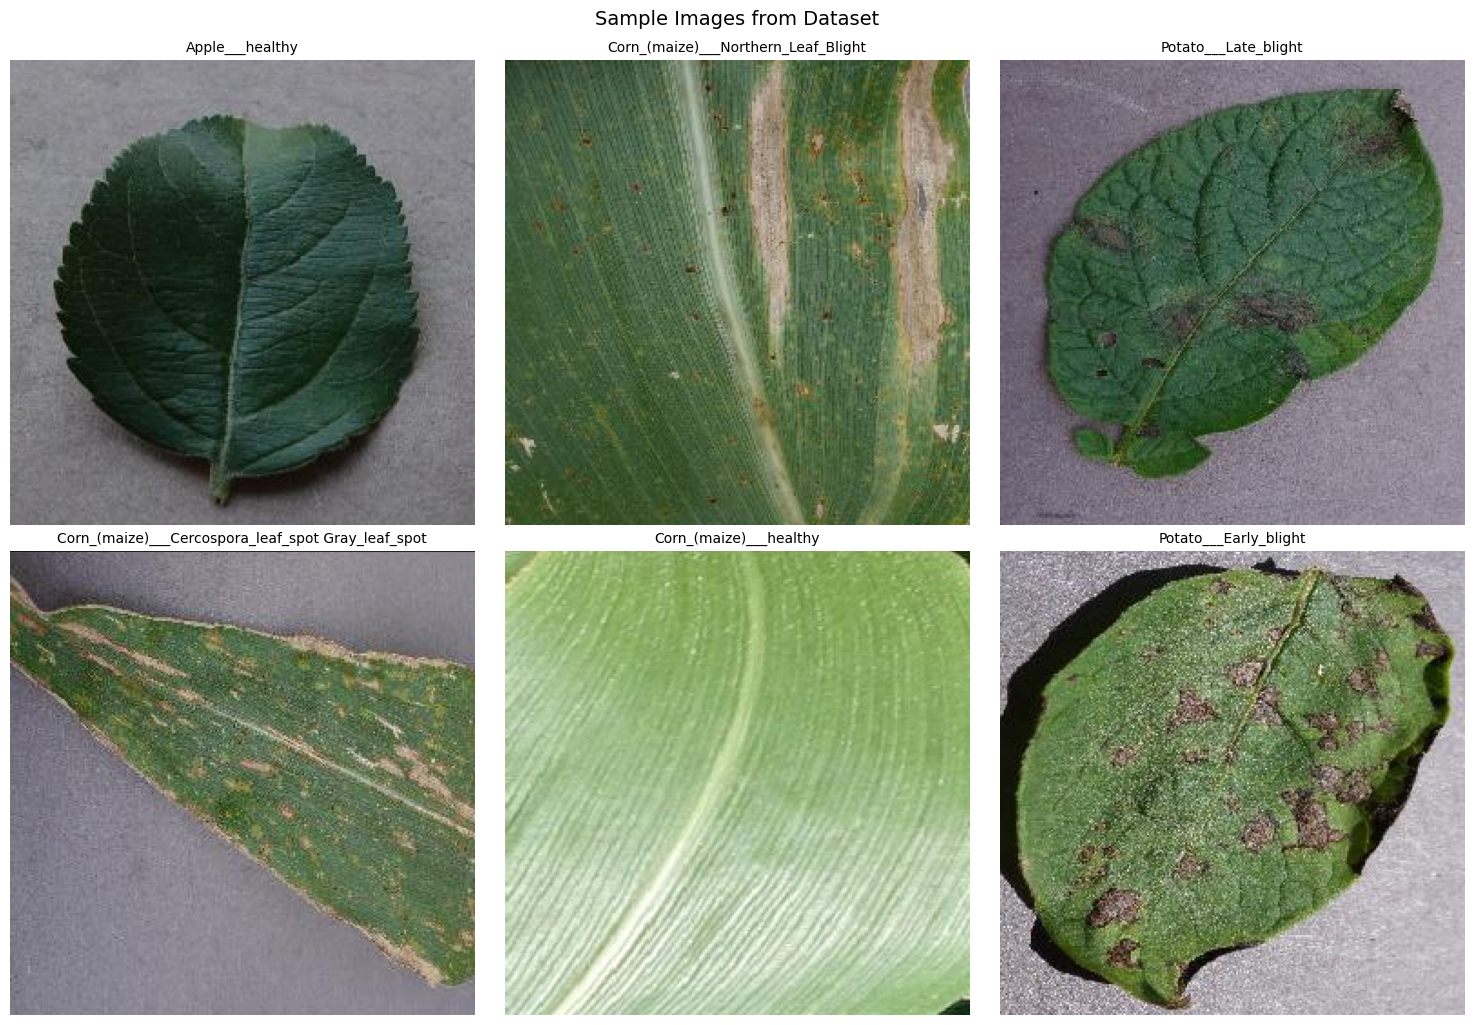

In [11]:
# Visualize sample images
import random

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

sample_classes = random.sample(class_names, min(6, len(class_names)))

for idx, class_name in enumerate(sample_classes):
    class_path = os.path.join(train_dir, class_name)
    images = [f for f in os.listdir(class_path) 
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if images:
        img_path = os.path.join(class_path, random.choice(images))
        img = Image.open(img_path).convert('RGB')
        axes[idx].imshow(img)
        axes[idx].set_title(class_name, fontsize=10)
        axes[idx].axis('off')

plt.tight_layout()
plt.suptitle('Sample Images from Dataset', fontsize=14, y=1.02)
plt.show()

## 5. Create Custom Dataset Class

In [12]:
class PlantDiseaseDataset(Dataset):
    def __init__(self, data_dir, label2id, processor, augment=False):
        self.data_dir = data_dir
        self.label2id = label2id
        self.processor = processor
        self.augment = augment
        
        # Collect all image paths and labels
        self.image_paths = []
        self.labels = []
        
        for class_name in sorted(os.listdir(data_dir)):
            class_path = os.path.join(data_dir, class_name)
            if os.path.isdir(class_path) and not class_name.startswith('.'):
                label_id = label2id[class_name]
                
                for img_name in os.listdir(class_path):
                    if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.image_paths.append(os.path.join(class_path, img_name))
                        self.labels.append(label_id)
        
        print(f"Loaded {len(self.image_paths)} images from {data_dir}")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Load image
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        
        # Apply augmentation if training
        if self.augment:
            image = self._augment(image)
        
        # Process image using ViT processor
        encoding = self.processor(images=image, return_tensors="pt")
        
        # Remove batch dimension
        pixel_values = encoding['pixel_values'].squeeze()
        
        return {
            'pixel_values': pixel_values,
            'labels': torch.tensor(label, dtype=torch.long)
        }
    
    def _augment(self, image):
        """Apply random augmentations"""
        augmentation = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(20),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        ])
        return augmentation(image)

## 6. Load Pretrained Model and Processor

In [13]:
# Load the image processor
processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
print(f"✓ Loaded image processor for {MODEL_NAME}")

# Load the pretrained model
model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True  # Important: allows changing the classifier head
)

# Move model to appropriate device (MPS/CUDA/CPU)
model = model.to(device)

print(f"✓ Loaded pretrained model: {MODEL_NAME}")
print(f"✓ Model configured for {num_classes} classes")
print(f"✓ Model moved to device: {device}")

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel Parameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")

✓ Loaded image processor for google/vit-base-patch16-224


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([11]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([11, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Loaded pretrained model: google/vit-base-patch16-224
✓ Model configured for 11 classes
✓ Model moved to device: mps

Model Parameters:
  Total: 85,807,115
  Trainable: 85,807,115


## 7. Create Datasets

In [14]:
# Create datasets
print("Creating datasets...\n")

train_dataset = PlantDiseaseDataset(
    train_dir, 
    label2id, 
    processor, 
    augment=True
)

valid_dataset = PlantDiseaseDataset(
    valid_dir, 
    label2id, 
    processor, 
    augment=False
)

if os.path.exists(test_dir):
    test_dataset = PlantDiseaseDataset(
        test_dir, 
        label2id, 
        processor, 
        augment=False
    )
else:
    test_dataset = valid_dataset
    print("\nUsing validation set as test set")

print(f"\n✓ Datasets created successfully")

Creating datasets...

Loaded 20789 images from /Users/madhavkhaitan/Desktop/PHYTO_Guard/train
Loaded 5198 images from /Users/madhavkhaitan/Desktop/PHYTO_Guard/valid
Loaded 0 images from /Users/madhavkhaitan/Desktop/PHYTO_Guard/test

✓ Datasets created successfully


## 8. Define Metrics and Training Arguments

In [15]:
# Define metrics computation
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted'
    )
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

print("✓ Metrics function defined")

✓ Metrics function defined


In [21]:
# Define training arguments optimized for MacBook
output_dir = os.path.join(base_path, 'vit_base_model_output')

# MacBook-specific optimizations
if device.type == "mps":
    # MPS (Apple Silicon) settings
    use_mps_device = True
    fp16 = False  # MPS doesn't support fp16 well yet
    dataloader_num_workers = 0  # Set to 0 for Jupyter notebooks to avoid multiprocessing issues
elif device.type == "cuda":
    use_mps_device = False
    fp16 = True
    dataloader_num_workers = 0  # Set to 0 for Jupyter notebooks
else:
    # CPU settings
    use_mps_device = False
    fp16 = False
    dataloader_num_workers = 0  # Safer for CPU

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_dir=os.path.join(output_dir, 'logs'),
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    push_to_hub=False,
    remove_unused_columns=False,
    report_to="none",
    use_mps_device=use_mps_device,
    fp16=fp16,
    dataloader_num_workers=dataloader_num_workers,
    dataloader_pin_memory=False,  # Disable for Jupyter notebooks
    disable_tqdm=False,  # Enable progress bar
)

print("✓ Training arguments configured for MacBook")
print(f"  Output directory: {output_dir}")
print(f"  Device optimization: {device.type.upper()}")
print(f"  Using MPS: {use_mps_device}")
print(f"  FP16: {fp16}")
print(f"  DataLoader workers: {dataloader_num_workers}")
print(f"  Progress bar: Enabled")


✓ Training arguments configured for MacBook
  Output directory: /Users/madhavkhaitan/Desktop/PHYTO_Guard/vit_base_model_output
  Device optimization: MPS
  Using MPS: True
  FP16: False
  DataLoader workers: 0
  Progress bar: Enabled


## 9. Create Trainer and Start Training

In [22]:
# Create Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
)

print("✓ Trainer created")
print("\nStarting training...\n")
print("=" * 70)

✓ Trainer created

Starting training...



In [23]:
# Train the model
train_result = trainer.train()

print("\n" + "=" * 70)
print("✓ Training completed!")
print("=" * 70)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.017000,0.020006,0.994613,0.994744,0.994613,0.994614
2,0.013100,0.007944,0.997114,0.997114,0.997114,0.997113
3,0.005100,0.010277,0.997307,0.997321,0.997307,0.997304
4,0.000300,0.005030,0.998846,0.998850,0.998846,0.998845
5,0.001900,0.010909,0.996922,0.996943,0.996922,0.996921
6,0.000100,0.004413,0.999230,0.999233,0.999230,0.999230
7,0.000000,0.002208,0.999423,0.999424,0.999423,0.999423
8,0.000000,0.002003,0.999808,0.999808,0.999808,0.999808
9,0.000000,0.002257,0.999615,0.999616,0.999615,0.999615
10,0.000000,0.002385,0.999615,0.999616,0.999615,0.999615



✓ Training completed!


## 10. Training Results and Visualization

In [24]:
# Get training history
log_history = trainer.state.log_history

# Extract metrics
train_loss = []
eval_loss = []
eval_accuracy = []
epochs = []

for entry in log_history:
    if 'loss' in entry and 'epoch' in entry:
        train_loss.append(entry['loss'])
    if 'eval_loss' in entry:
        eval_loss.append(entry['eval_loss'])
        eval_accuracy.append(entry['eval_accuracy'])
        epochs.append(entry['epoch'])

print(f"Final training loss: {train_loss[-1]:.4f}")
print(f"Final validation loss: {eval_loss[-1]:.4f}")
print(f"Final validation accuracy: {eval_accuracy[-1]:.4f}")

Final training loss: 0.0000
Final validation loss: 0.0024
Final validation accuracy: 0.9996


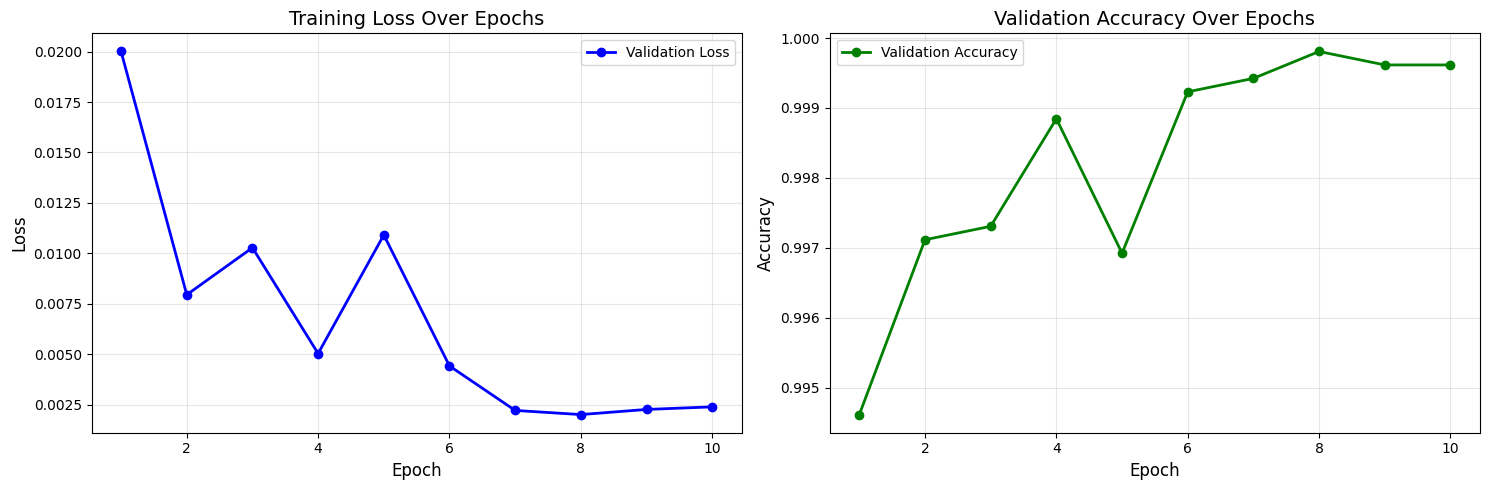


Best validation accuracy: 0.9998 at epoch 8


In [25]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(epochs, eval_loss, 'b-o', label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss Over Epochs', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs, eval_accuracy, 'g-o', label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Validation Accuracy Over Epochs', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print best metrics
best_accuracy = max(eval_accuracy)
best_epoch = epochs[eval_accuracy.index(best_accuracy)]
print(f"\nBest validation accuracy: {best_accuracy:.4f} at epoch {int(best_epoch)}")

## 11. Evaluate on Test Set

In [26]:
# Evaluate on test set
print("Evaluating on test set...\n")
test_results = trainer.evaluate(test_dataset)

print("Test Results:")
print("=" * 60)
for key, value in test_results.items():
    print(f"{key:20s}: {value:.4f}")
print("=" * 60)

Evaluating on test set...

Test Results:
eval_runtime        : 0.0035
eval_samples_per_second: 0.0000
eval_steps_per_second: 0.0000
epoch               : 10.0000


## 12. Generate Predictions and Confusion Matrix

In [35]:
# Get predictions
print("Generating predictions on test set...\n")

# Check if model has been trained
if not hasattr(trainer, 'state') or trainer.state.log_history == []:
    print("⚠ Error: Model hasn't been trained yet!")
    print("Please run the training cell first before generating predictions.")
    raise RuntimeError("Model not trained. Run trainer.train() first.")

# Use validation set since test directory doesn't have proper class structure
eval_dataset_for_prediction = valid_dataset
print(f"Using validation set for predictions (test dir doesn't have class folders)")
print(f"Dataset size: {len(eval_dataset_for_prediction)} samples")
print(f"Model device: {next(model.parameters()).device}\n")

# Generate predictions
print("Running prediction...")
prediction_output = trainer.predict(eval_dataset_for_prediction)

# Extract predictions - handle both logits and pre-computed predictions
if prediction_output.predictions is None:
    print("⚠ Trainer.predict() returned None, using manual prediction...")
    
    # Manual prediction as fallback
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for i in range(len(eval_dataset_for_prediction)):
            sample = eval_dataset_for_prediction[i]
            pixel_values = sample['pixel_values'].unsqueeze(0).to(device)
            label = sample['labels'].item()
            
            outputs = model(pixel_values=pixel_values)
            pred = outputs.logits.argmax(-1).item()
            
            all_preds.append(pred)
            all_labels.append(label)
            
            if (i + 1) % 100 == 0:
                print(f"  Processed {i + 1}/{len(eval_dataset_for_prediction)} samples...")
    
    y_pred = np.array(all_preds)
    y_true = np.array(all_labels)
    print(f"✓ Manual prediction completed for {len(y_pred)} samples")
    
else:
    # Normal prediction flow
    pred_logits = prediction_output.predictions
    print(f"Predictions shape: {pred_logits.shape}")
    
    # If predictions are logits (2D with shape [n_samples, n_classes]), take argmax
    if len(pred_logits.shape) == 2:
        y_pred = np.argmax(pred_logits, axis=1)
    elif len(pred_logits.shape) == 1:
        # Already class indices
        y_pred = pred_logits.astype(int)
    else:
        raise ValueError(f"Unexpected predictions shape: {pred_logits.shape}")
    
    y_true = prediction_output.label_ids
    print(f"✓ Generated predictions for {len(y_pred)} samples")


Generating predictions on test set...

Using validation set for predictions (test dir doesn't have class folders)
Dataset size: 5198 samples
Model device: mps:0

Running prediction...


Predictions shape: (5198, 11)
✓ Generated predictions for 5198 samples


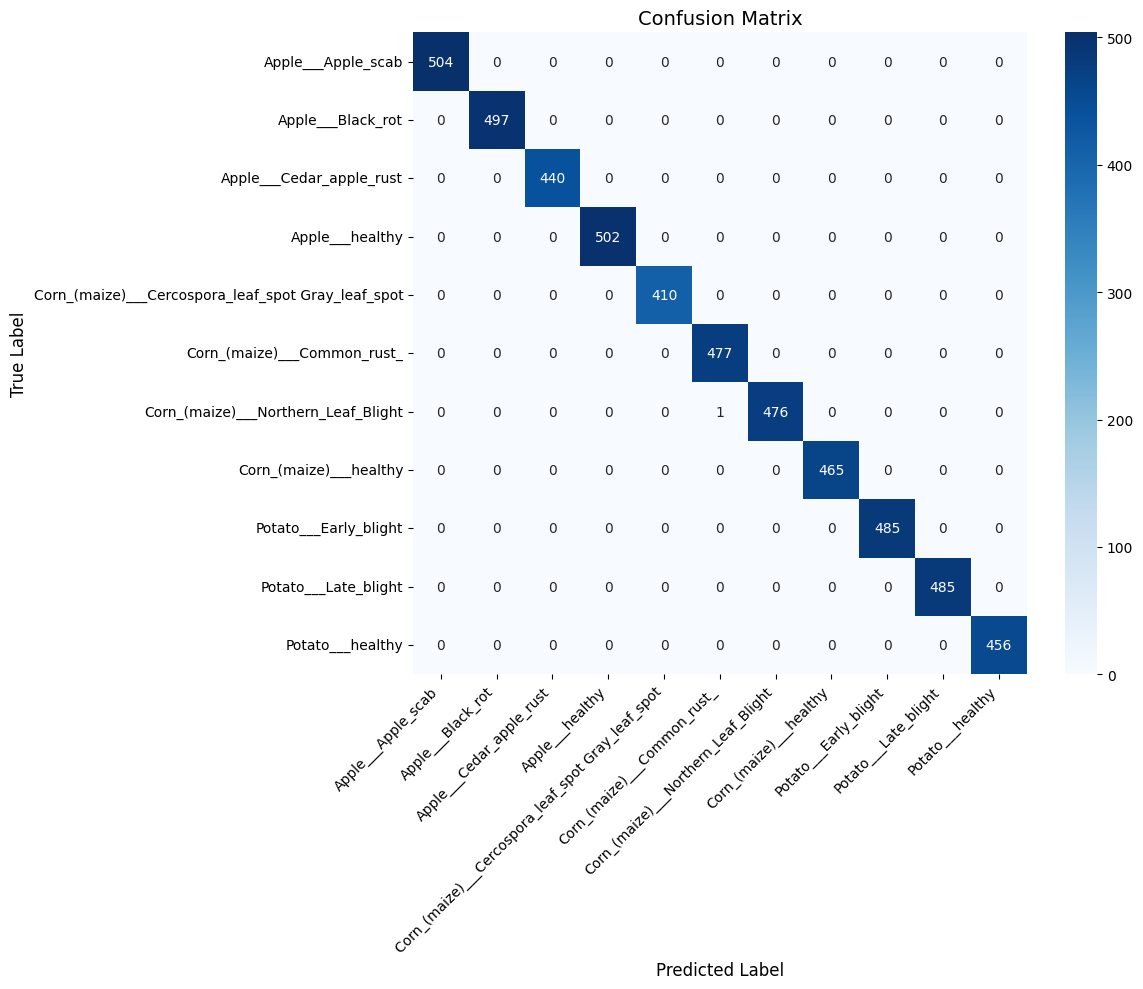

In [37]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

if num_classes <= 15:
    # Plot full confusion matrix for smaller datasets
    plt.figure(figsize=(max(12, num_classes), max(10, num_classes * 0.8)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title('Confusion Matrix', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    # Show aggregated metrics for larger datasets
    print(f"\nNote: With {num_classes} classes, showing aggregated metrics")
    print("=" * 70)
    
    # Per-class accuracy
    class_accuracy = cm.diagonal() / cm.sum(axis=1)
    
    print(f"\nOverall Accuracy: {cm.diagonal().sum() / cm.sum():.4f}")
    print(f"Mean per-class accuracy: {class_accuracy.mean():.4f}")
    print(f"Median per-class accuracy: {np.median(class_accuracy):.4f}")
    
    # Best and worst classes
    sorted_indices = np.argsort(class_accuracy)
    
    print("\nTop 5 Best Performing Classes:")
    for idx in sorted_indices[-5:][::-1]:
        print(f"  {class_names[idx]}: {class_accuracy[idx]:.4f}")
    
    print("\nTop 5 Worst Performing Classes:")
    for idx in sorted_indices[:5]:
        print(f"  {class_names[idx]}: {class_accuracy[idx]:.4f}")

## 13. Classification Report

In [38]:
# Generate classification report
print("Classification Report")
print("=" * 80)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
print("=" * 80)

Classification Report
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    1.0000    1.0000       504
                                 Apple___Black_rot     1.0000    1.0000    1.0000       497
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000       440
                                   Apple___healthy     1.0000    1.0000    1.0000       502
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     1.0000    1.0000    1.0000       410
                       Corn_(maize)___Common_rust_     0.9979    1.0000    0.9990       477
               Corn_(maize)___Northern_Leaf_Blight     1.0000    0.9979    0.9990       477
                            Corn_(maize)___healthy     1.0000    1.0000    1.0000       465
                             Potato___Early_blight     1.0000    1.0000    1.0000       485
                              Potato___Late_blight     1.

## 14. Save Model and Results

In [39]:
# Save the final model in saved_models folder
saved_models_dir = os.path.join(base_path, 'saved_models')
os.makedirs(saved_models_dir, exist_ok=True)

final_model_path = os.path.join(saved_models_dir, 'vit_base_patch16_final')
trainer.save_model(final_model_path)
processor.save_pretrained(final_model_path)

print(f"✓ Model saved to: {final_model_path}")

# Save label mappings
mappings = {
    'label2id': label2id,
    'id2label': id2label,
    'class_names': class_names
}

mappings_path = os.path.join(saved_models_dir, 'vit_base_label_mappings.json')
with open(mappings_path, 'w') as f:
    json.dump(mappings, f, indent=4)

print(f"✓ Label mappings saved to: {mappings_path}")

# Save training history
history = {
    'epochs': epochs,
    'eval_loss': eval_loss,
    'eval_accuracy': eval_accuracy,
    'test_results': test_results
}

history_path = os.path.join(saved_models_dir, 'vit_base_training_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f, indent=4)

print(f"✓ Training history saved to: {history_path}")

# Save classification report (only if predictions have been generated)
if 'y_true' in globals() and 'y_pred' in globals() and y_true is not None and y_pred is not None:
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    report_path = os.path.join(saved_models_dir, 'vit_base_classification_report.json')
    with open(report_path, 'w') as f:
        json.dump(report_dict, f, indent=4)
    print(f"✓ Classification report saved to: {report_path}")
else:
    print("⚠ Classification report not saved (run prediction cell first)")

print("\n" + "=" * 70)
print("All files saved successfully in saved_models folder!")
print(f"Location: {saved_models_dir}")
print("=" * 70)


✓ Model saved to: /Users/madhavkhaitan/Desktop/PHYTO_Guard/saved_models/vit_base_patch16_final
✓ Label mappings saved to: /Users/madhavkhaitan/Desktop/PHYTO_Guard/saved_models/vit_base_label_mappings.json
✓ Training history saved to: /Users/madhavkhaitan/Desktop/PHYTO_Guard/saved_models/vit_base_training_history.json
✓ Classification report saved to: /Users/madhavkhaitan/Desktop/PHYTO_Guard/saved_models/vit_base_classification_report.json

All files saved successfully in saved_models folder!
Location: /Users/madhavkhaitan/Desktop/PHYTO_Guard/saved_models


## 15. Test Prediction Function

In [42]:
# Function to predict a single image
def predict_image(image_path, model, processor, id2label):
    """
    Predict the class of a single image
    """
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    inputs = processor(images=image, return_tensors="pt")
    
    # Move to same device as model
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Get prediction
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probabilities = torch.nn.functional.softmax(logits, dim=-1)
        predicted_class_idx = logits.argmax(-1).item()
        confidence = probabilities[0][predicted_class_idx].item()
    
    predicted_class = id2label[predicted_class_idx]
    
    return predicted_class, confidence, probabilities[0].cpu().numpy()

print("✓ Prediction function defined")

✓ Prediction function defined


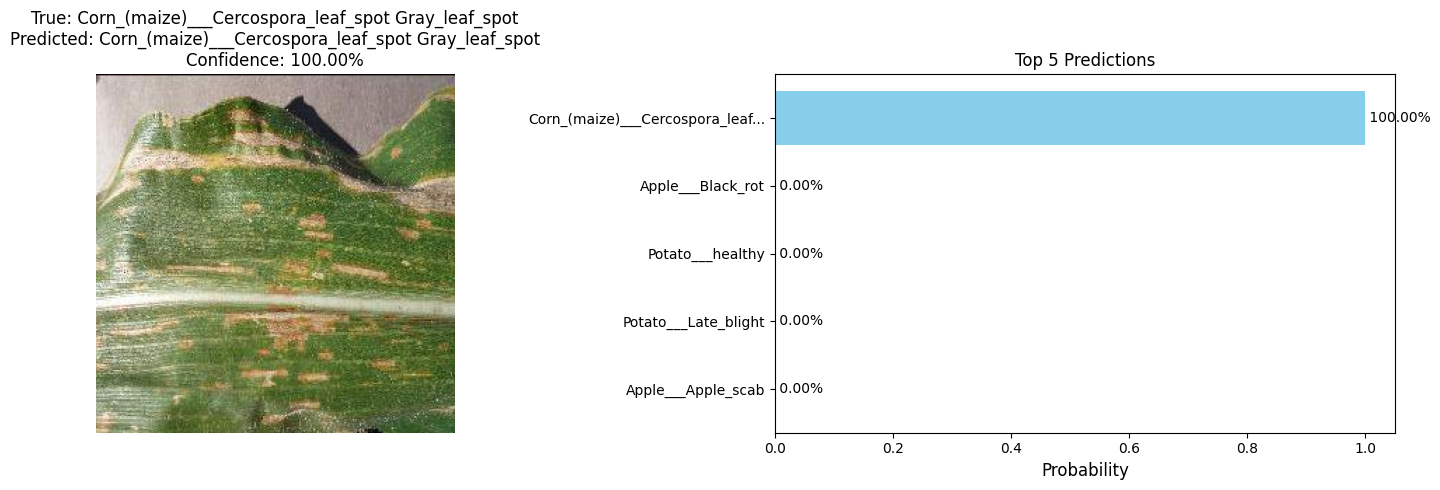


True label: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Predicted: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Confidence: 100.00%
Correct: ✓


In [43]:
# Test prediction on a random image
import random

# Select a random class and image from validation set
test_class = random.choice(class_names)
test_class_path = os.path.join(valid_dir, test_class)
test_images = [f for f in os.listdir(test_class_path) 
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
test_image_name = random.choice(test_images)
test_image_path = os.path.join(test_class_path, test_image_name)

# Make prediction
predicted_class, confidence, probabilities = predict_image(
    test_image_path, model, processor, id2label
)

# Display results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Show image
img = Image.open(test_image_path)
ax1.imshow(img)
ax1.axis('off')
ax1.set_title(f'True: {test_class}\nPredicted: {predicted_class}\nConfidence: {confidence:.2%}', 
              fontsize=12)

# Show top 5 predictions
top_k = 5
top_indices = np.argsort(probabilities)[-top_k:][::-1]
top_labels = [id2label[idx] for idx in top_indices]
top_probs = [probabilities[idx] for idx in top_indices]

ax2.barh(range(top_k), top_probs, color='skyblue')
ax2.set_yticks(range(top_k))
ax2.set_yticklabels([f"{label[:30]}..." if len(label) > 30 else label for label in top_labels])
ax2.set_xlabel('Probability', fontsize=12)
ax2.set_title(f'Top {top_k} Predictions', fontsize=12)
ax2.invert_yaxis()

for i, prob in enumerate(top_probs):
    ax2.text(prob, i, f' {prob:.2%}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nTrue label: {test_class}")
print(f"Predicted: {predicted_class}")
print(f"Confidence: {confidence:.2%}")
print(f"Correct: {'✓' if test_class == predicted_class else '✗'}")

## Summary

✅ **Model trained successfully!**

### Output Files:
- `vit_base_patch16_final/` - Trained model and processor
- `vit_base_label_mappings.json` - Label mappings
- `vit_base_training_history.json` - Training metrics
- `vit_base_classification_report.json` - Detailed evaluation

### To use the model:
```python
from transformers import ViTForImageClassification, ViTImageProcessor

model = ViTForImageClassification.from_pretrained('vit_base_patch16_final')
processor = ViTImageProcessor.from_pretrained('vit_base_patch16_final')
```